In [ ]:
symbol      = '^NSEI'               # '^NSEI' 'TCS.NS'
period      = 'max'                 #   "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y","5y", "10y", "ytd", "max"
interval    = '1d'                  #   "1m", "2m", "5m", "15m", "30m", "60m"/"1h", "90m",      "1d", "5d", "1wk", "1mo", "3mo"

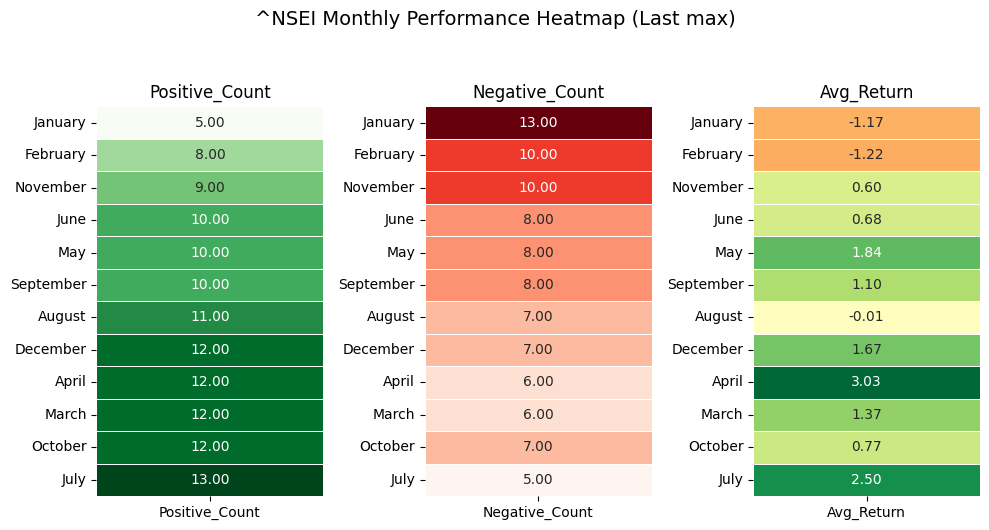

In [ ]:
from IPython.display import clear_output
clear_output()
import warnings
from IPython.display import clear_output, display

# Filter out the specific FutureWarning from yfinance
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
clear_output()

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

#------------------------------------------------------------------------------------------

nifty = yf.download(symbol, period=period, interval=interval, progress=False, auto_adjust=True)
nifty.columns = nifty.columns.get_level_values(0)

monthly_close = nifty['Close'].resample('ME').last()

monthly_returns = monthly_close.pct_change() * 100
# display(monthly_returns)

# Create dataframe with Year-Month
monthly_data = pd.DataFrame({
    'Year': monthly_returns.index.year,
    'Month': monthly_returns.index.month_name(),
    'Monthly Return (%)': monthly_returns.values
})

month_summary = monthly_data.groupby('Month')['Monthly Return (%)'].agg(
    Positive_Count=lambda x: (x > 0).sum(),
    Negative_Count=lambda x: (x < 0).sum(),
    Avg_Return=lambda x: round(x.mean(), 2)
).reset_index()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_summary['Month'] = pd.Categorical(month_summary['Month'], categories=month_order, ordered=True)
month_summary = month_summary.sort_values('Positive_Count')

# display(month_summary)

#------------------------------------------------------------------------------------------

from matplotlib import gridspec
import seaborn as sns  # Import seaborn

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

cols = ['Positive_Count', 'Negative_Count', 'Avg_Return']
cmaps = ['Greens', 'Reds', 'RdYlGn']

# Set 'Month' as index for heatmap
month_summary_indexed = month_summary.set_index('Month')

for i, (col, cmap) in enumerate(zip(cols, cmaps)):
    ax = plt.subplot(gs[i])
    # Use month_summary_indexed instead of month_summary
    sns.heatmap(
        month_summary_indexed[[col]], annot=True, fmt=".2f",
        cmap=cmap, center=0 if col == 'Avg_Return' else None,
        linewidths=.5, cbar=False, ax=ax, yticklabels=True  # Ensure yticklabels are shown
    )
    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("")
    # ax.yaxis.set_tick_params(labelleft=(i == 0))  # Remove this line as we want labels on all heatmaps for clarity

plt.suptitle(f"{symbol} Monthly Performance Heatmap (Last {period})", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


✅ Quarterly ^NSEI Summary (Last max):


,Quarter,Avg_Return,Positive_Count,Negative_Count,Best_Return,Worst_Return,Quarter_Name
0,1,-1.04,10,8,14.52,-29.34,Q1 (Jan-Mar)
1,2,5.69,13,5,42.04,-14.66,Q2 (Apr-Jun)
2,3,3.57,12,6,18.48,-12.47,Q3 (Jul-Sep)
3,4,3.03,12,7,24.31,-24.53,Q4 (Oct-Dec)


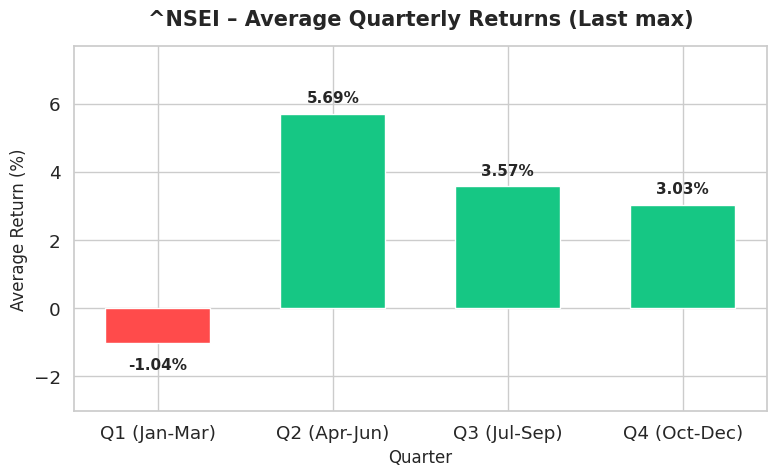

In [ ]:
# How Nifty Performed Each Quarter

nifty = yf.download(symbol, period=period, interval=interval, progress=False, auto_adjust=True)
nifty.columns = nifty.columns.get_level_values(0)

quarterly_close = nifty['Close'].resample('QE').last()
quarterly_returns = quarterly_close.pct_change() * 100

quarterly_data = pd.DataFrame({
    'Quarter_End': quarterly_returns.index,
    'Quarterly Return (%)': quarterly_returns.values
})

quarterly_data['Year'] = quarterly_data['Quarter_End'].dt.year
quarterly_data['Quarter'] = quarterly_data['Quarter_End'].dt.quarter

# display(quarterly_data)

quarterly_summary = quarterly_data.groupby('Quarter')['Quarterly Return (%)'].agg(
    Avg_Return=lambda x: round(x.mean(), 2),
    Positive_Count=lambda x: (x > 0).sum(),
    Negative_Count=lambda x: (x < 0).sum(),
    Best_Return=lambda x: round(x.max(), 2),
    Worst_Return=lambda x: round(x.min(), 2)
).reset_index()

quarter_map = {1: "Q1 (Jan-Mar)", 2: "Q2 (Apr-Jun)", 3: "Q3 (Jul-Sep)", 4: "Q4 (Oct-Dec)"}
quarterly_summary['Quarter_Name'] = quarterly_summary['Quarter'].map(quarter_map)

quarterly_summary = quarterly_summary.sort_values('Quarter').reset_index(drop=True)

print(f"\n✅ Quarterly {symbol} Summary (Last {period}):")
display(quarterly_summary)

#------------------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", font_scale=1.2)

# Colors
colors = ["#16C784" if val > 0 else "#FF4B4B" for val in quarterly_summary['Avg_Return']]

plt.figure(figsize=(8, 5))
bars = plt.bar(quarterly_summary['Quarter_Name'], quarterly_summary['Avg_Return'], color=colors, width=0.6)

# Adjust annotation position dynamically
for i, val in enumerate(quarterly_summary['Avg_Return']):
    if val >= 0:
        plt.text(i, val + 0.25, f"{val:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        plt.text(i, val - 0.4, f"{val:.2f}%", ha='center', va='top', fontsize=11, fontweight='bold')

# Titles & labels
plt.title(f"{symbol} – Average Quarterly Returns (Last {period})", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Quarter", fontsize=12)
plt.ylabel("Average Return (%)", fontsize=12)

# Adjust Y-axis limits for better spacing above bars
y_min = min(quarterly_summary['Avg_Return']) - 2
y_max = max(quarterly_summary['Avg_Return']) + 2
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

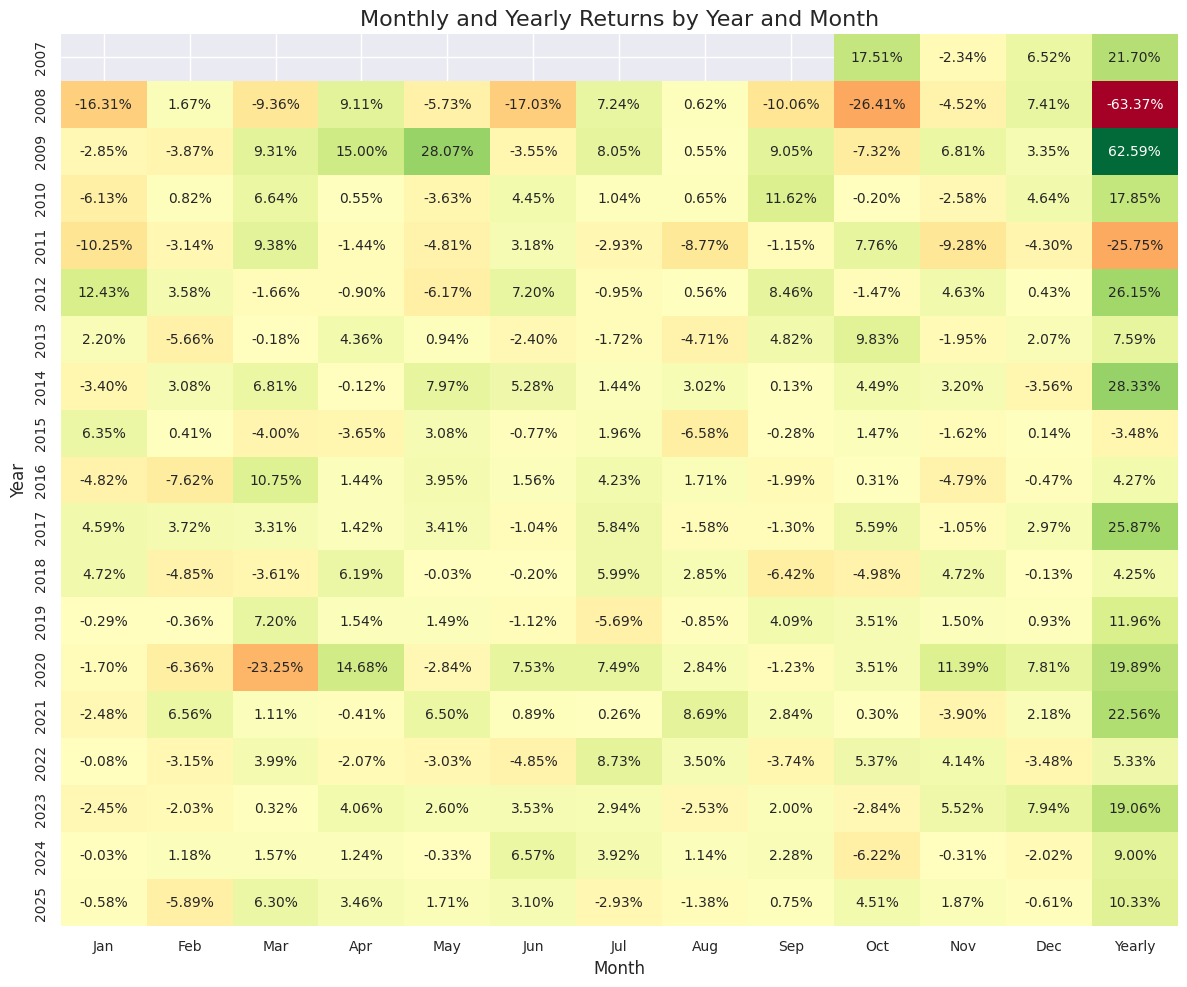

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ticker      = "^NSEI"
# start_date  = "2000-01-01"
# end_date    = "2025-12-27"

# # Download the historical data for Nifty Index
# data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, progress=False, multi_level_index=None, rounding=True)

#------------------------------------------------------------------------------------------

symbol      = '^NSEI'               # '^NSEI' 'TCS.NS'
period      = 'max'                 #   "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y","5y", "10y", "ytd", "max"
interval    = '1d'                  #   "1m", "2m", "5m", "15m", "30m", "60m"/"1h", "90m",      "1d", "5d", "1wk", "1mo", "3mo"

# # Download the historical data for Nifty Index
data = yf.download(symbol, period=period, interval=interval, auto_adjust=False, progress=False, multi_level_index=None, rounding=True)

# Resample the data on a monthly basis
data_monthly = data.resample('ME').last()

# Calculate the monthly returns
monthly_returns = data_monthly['Adj Close'].pct_change()

# Convert monthly returns to a pandas DataFrame
monthly_returns_df = pd.DataFrame(monthly_returns)

# Pivot the DataFrame to create a matrix of monthly returns by year and month
monthly_returns_matrix = monthly_returns_df.pivot_table(values='Adj Close', index=monthly_returns_df.index.year, columns=monthly_returns_df.index.month)

# Set the column names to the month names
monthly_returns_matrix.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate the sum of monthly returns for each year
yearly_returns = monthly_returns_df.groupby(monthly_returns_df.index.year)['Adj Close'].sum()

# Add the yearly returns to the matrix as a new column
monthly_returns_matrix['Yearly'] = yearly_returns

# Reduce global font scale
sns.set(font_scale=0.9)

plt.figure(figsize=(12, 10))

sns.heatmap(monthly_returns_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2%', cbar=False, annot_kws={"size": 10})

# Title & labels
plt.title('Monthly and Yearly Returns by Year and Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Tick label sizes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

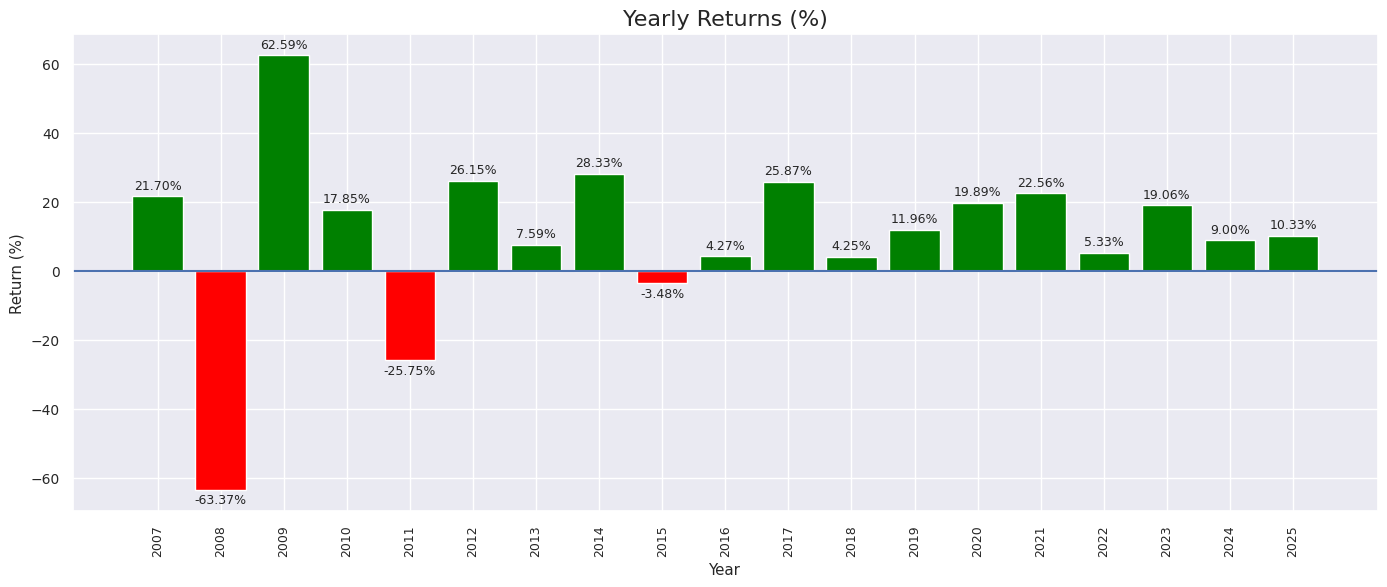

In [ ]:
# Convert yearly returns to percentage
yearly_returns_pct = yearly_returns * 100

colors = ['green' if x >= 0 else 'red' for x in yearly_returns_pct]

plt.figure(figsize=(14, 6))

bars = plt.bar(
    yearly_returns_pct.index.astype(str),
    yearly_returns_pct.values,
    color=colors
)

# Zero line
plt.axhline(0)

# Add % labels on bars
plt.bar_label(
    bars,
    labels=[f"{v:.2f}%" for v in yearly_returns_pct.values],
    padding=3,
    fontsize=9
)

# Titles & labels
plt.title('Yearly Returns (%)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Return (%)')

# Improve readability
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

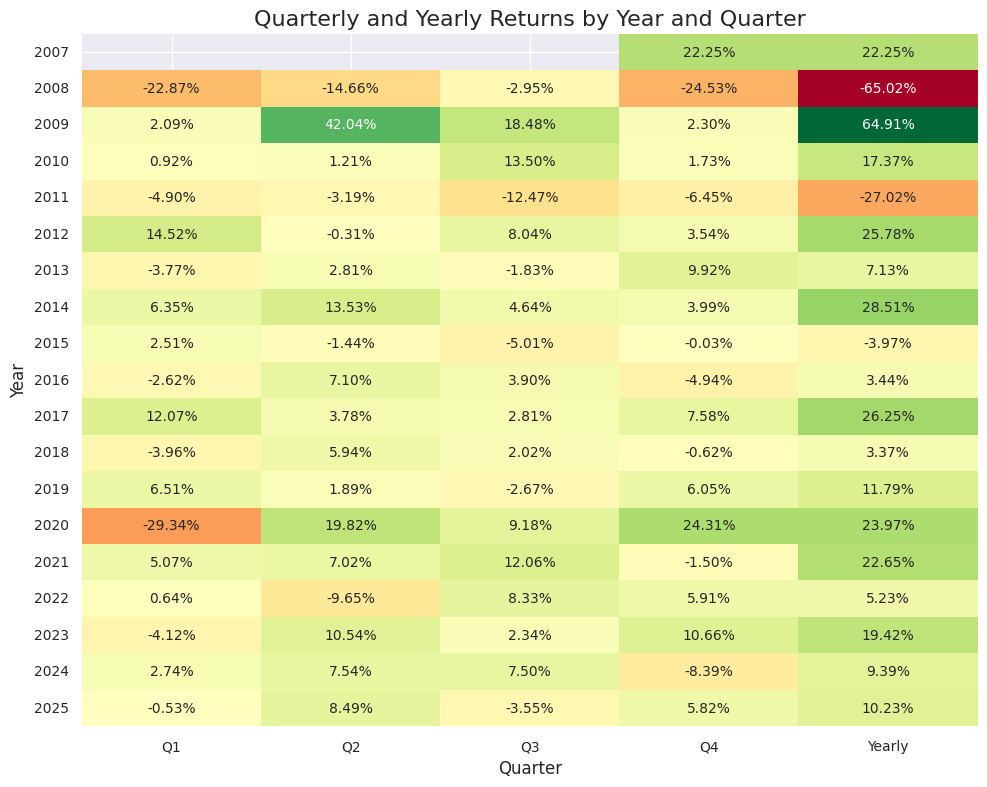

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

symbol      = '^NSEI'               # '^NSEI' 'TCS.NS'
period      = 'max'                 #   "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y","5y", "10y", "ytd", "max"
interval    = '1d'                  #   "1m", "2m", "5m", "15m", "30m", "60m"/"1h", "90m",      "1d", "5d", "1wk", "1mo", "3mo"

# # Download the historical data for Nifty Index
data = yf.download(symbol, period=period, interval=interval, auto_adjust=False, progress=False, multi_level_index=None, rounding=True)

# Resample the data on a quarterly basis
data_quarterly = data.resample('QE').last()

# Calculate the quarterly returns
quarterly_returns = data_quarterly['Adj Close'].pct_change()

# Convert quarterly returns to a pandas DataFrame
quarterly_returns_df = pd.DataFrame(quarterly_returns)

# Pivot the DataFrame to create a matrix of quarterly returns by year and quarter
quarterly_returns_matrix = quarterly_returns_df.pivot_table(values='Adj Close', index=quarterly_returns_df.index.year, columns=quarterly_returns_df.index.quarter)

# Set the column names to the quarter names
quarterly_returns_matrix.columns = ['Q1', 'Q2', 'Q3', 'Q4']

# Calculate the yearly returns as the sum of all quarterly returns for that year
yearly_returns = quarterly_returns_df.groupby(quarterly_returns_df.index.year)['Adj Close'].sum()

# Add the yearly returns to the matrix as a new column
quarterly_returns_matrix['Yearly'] = yearly_returns

# Set the font scale
sns.set(font_scale=0.9)

# Plot the heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(quarterly_returns_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2%', cbar=False, annot_kws={"size": 10})

# Title & labels
plt.title('Quarterly and Yearly Returns by Year and Quarter', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Tick label sizes
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# ===============================
# CONFIG
# ===============================
START = "2018-01-01"
END   = None

SECTORS = {
    "AUTO": "^CNXAUTO",
    "BANK": "^NSEBANK",
    "FMCG": "^CNXFMCG",
    "IT": "^CNXIT",
    "METAL": "^CNXMETAL",
    "PHARMA": "^CNXPHARMA",
    "PSU_BANK": "^CNXPSUBANK",
    "REALTY": "^CNXREALTY",
    "ENERGY": "^CNXENERGY",
    "FIN_SERVICE": "^CNXFIN"
}

# ===============================
# INDICATORS
# ===============================
def RSI(close, period=14):
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def ATR(df, period=14):
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift()).abs(),
        (df['Low'] - df['Close'].shift()).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(period).mean()

# ===============================
# ANALYSIS
# ===============================
rows = []

for sector, ticker in SECTORS.items():
    df = yf.download(
        ticker,
        start=START,
        end=END,
        auto_adjust=False,
        progress=False
    )

    if df.empty or len(df) < 200:
        continue

    df = df.dropna()

    df['EMA50']  = df['Close'].ewm(span=50).mean()
    df['EMA100'] = df['Close'].ewm(span=100).mean()
    df['RSI']    = RSI(df['Close'])
    df['ATR']    = ATR(df)

    weekly_close  = df['Close'].resample('W-FRI').last()
    monthly_close = df['Close'].resample('ME').last()

    weekly_ret  = weekly_close.pct_change().iloc[-1].item() * 100
    monthly_ret = monthly_close.pct_change().iloc[-1].item() * 100

    trend = "Bullish" if df['EMA50'].iloc[-1] > df['EMA100'].iloc[-1] else "Bearish"

    rows.append({
        "Sector": sector,
        "Weekly %": round(weekly_ret, 2),
        "Monthly %": round(monthly_ret, 2),
        "Trend": trend,
        "RSI": round(float(df['RSI'].iloc[-1]), 1),
        "ATR": round(float(df['ATR'].iloc[-1]), 2)
    })

# ===============================
# FINAL OUTPUT
# ===============================
sector_df = pd.DataFrame(rows)

sector_df = (
    sector_df
    .dropna()
    .sort_values(by="Monthly %", ascending=False)
    .reset_index(drop=True)
)

print("\n📊 NIFTY SECTORAL WEEKLY & MONTHLY ANALYSIS\n")
print(sector_df.to_string(index=False))


📊 NIFTY SECTORAL WEEKLY & MONTHLY ANALYSIS

  Sector  Weekly %  Monthly %   Trend  RSI    ATR
   METAL      2.71       4.98 Bullish 71.2 150.22
      IT     -0.31       3.12 Bullish 48.4 504.37
    AUTO      0.30      -0.13 Bullish 45.6 309.95
    FMCG      0.64      -0.83 Bearish 48.7 489.78
    BANK     -0.10      -1.24 Bullish 35.0 421.43
  PHARMA     -0.29      -1.36 Bullish 41.9 224.05
  ENERGY      0.75      -1.38 Bearish 51.6 388.60
  REALTY     -0.20      -2.21 Bearish 45.2  16.00
PSU_BANK     -0.84      -2.67 Bullish 44.2 114.76


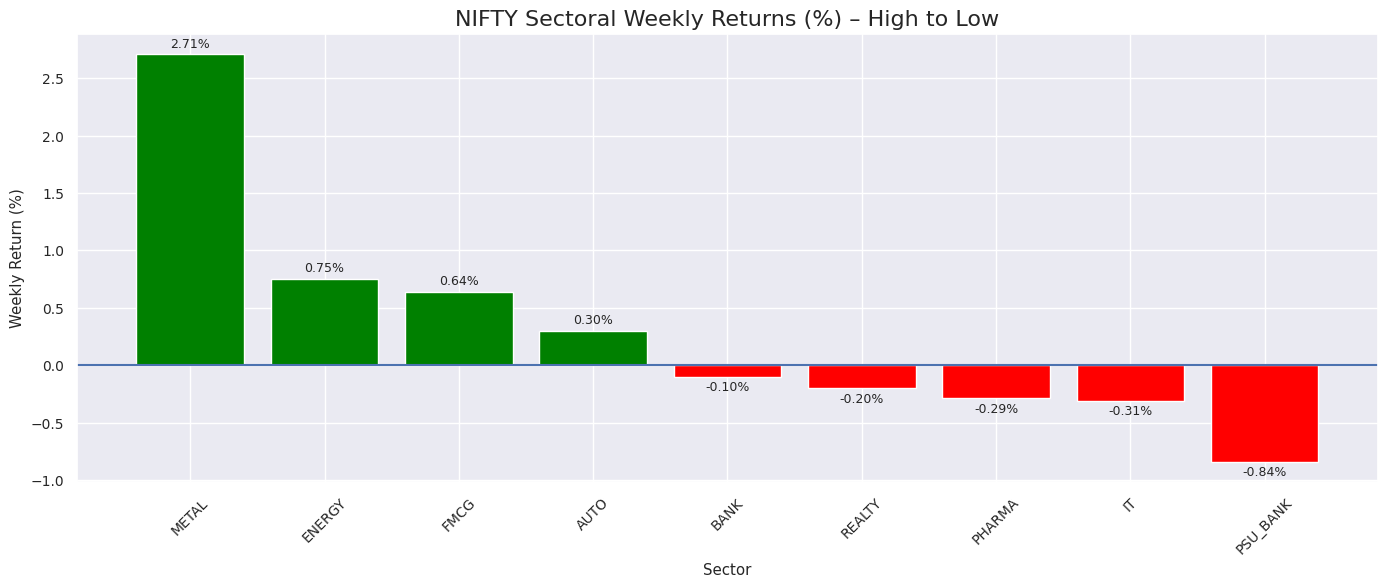

In [ ]:
import matplotlib.pyplot as plt

# Sort High → Low
weekly_sorted = sector_df.sort_values("Weekly %", ascending=False)

weekly_vals = weekly_sorted["Weekly %"]
weekly_colors = ['green' if x >= 0 else 'red' for x in weekly_vals]

plt.figure(figsize=(14, 6))

bars = plt.bar(
    weekly_sorted["Sector"],
    weekly_vals,
    color=weekly_colors
)

# Zero line
plt.axhline(0)

# % Labels
plt.bar_label(
    bars,
    labels=[f"{v:.2f}%" for v in weekly_vals],
    padding=3,
    fontsize=9
)

plt.title("NIFTY Sectoral Weekly Returns (%) – High to Low", fontsize=16)
plt.xlabel("Sector")
plt.ylabel("Weekly Return (%)")

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

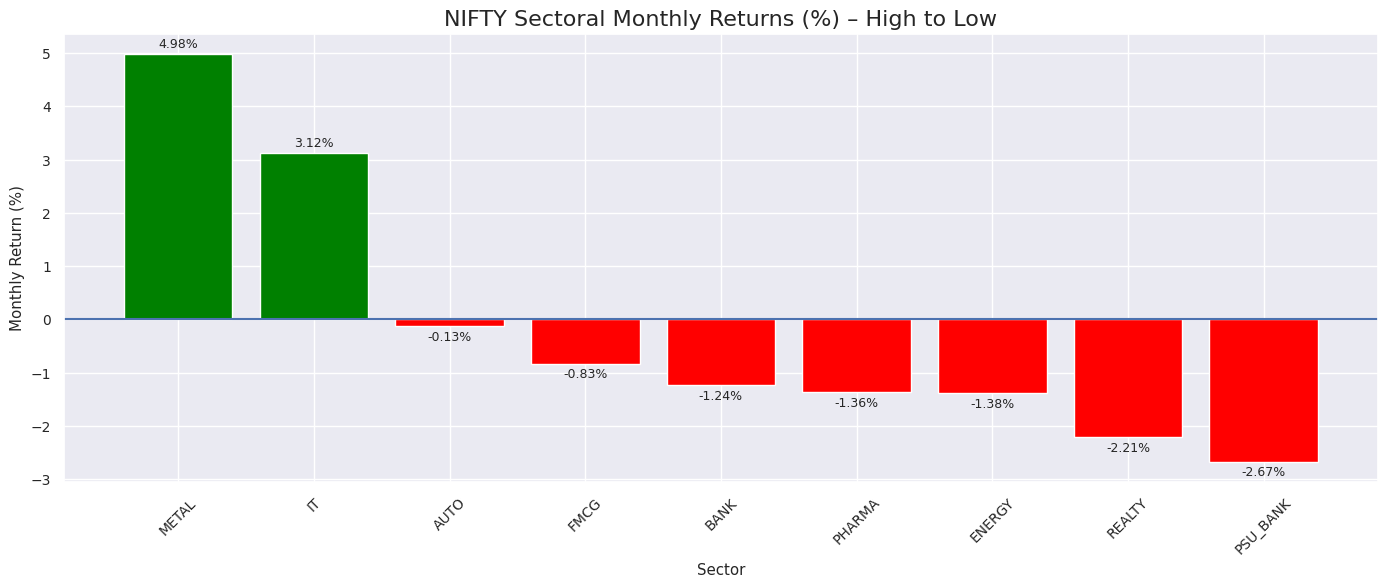

In [ ]:
import matplotlib.pyplot as plt

# Sort High → Low
monthly_sorted = sector_df.sort_values("Monthly %", ascending=False)

monthly_vals = monthly_sorted["Monthly %"]
monthly_colors = ['green' if x >= 0 else 'red' for x in monthly_vals]

plt.figure(figsize=(14, 6))

bars = plt.bar(
    monthly_sorted["Sector"],
    monthly_vals,
    color=monthly_colors
)

# Zero line
plt.axhline(0)

# % Labels
plt.bar_label(
    bars,
    labels=[f"{v:.2f}%" for v in monthly_vals],
    padding=3,
    fontsize=9
)

plt.title("NIFTY Sectoral Monthly Returns (%) – High to Low", fontsize=16)
plt.xlabel("Sector")
plt.ylabel("Monthly Return (%)")

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

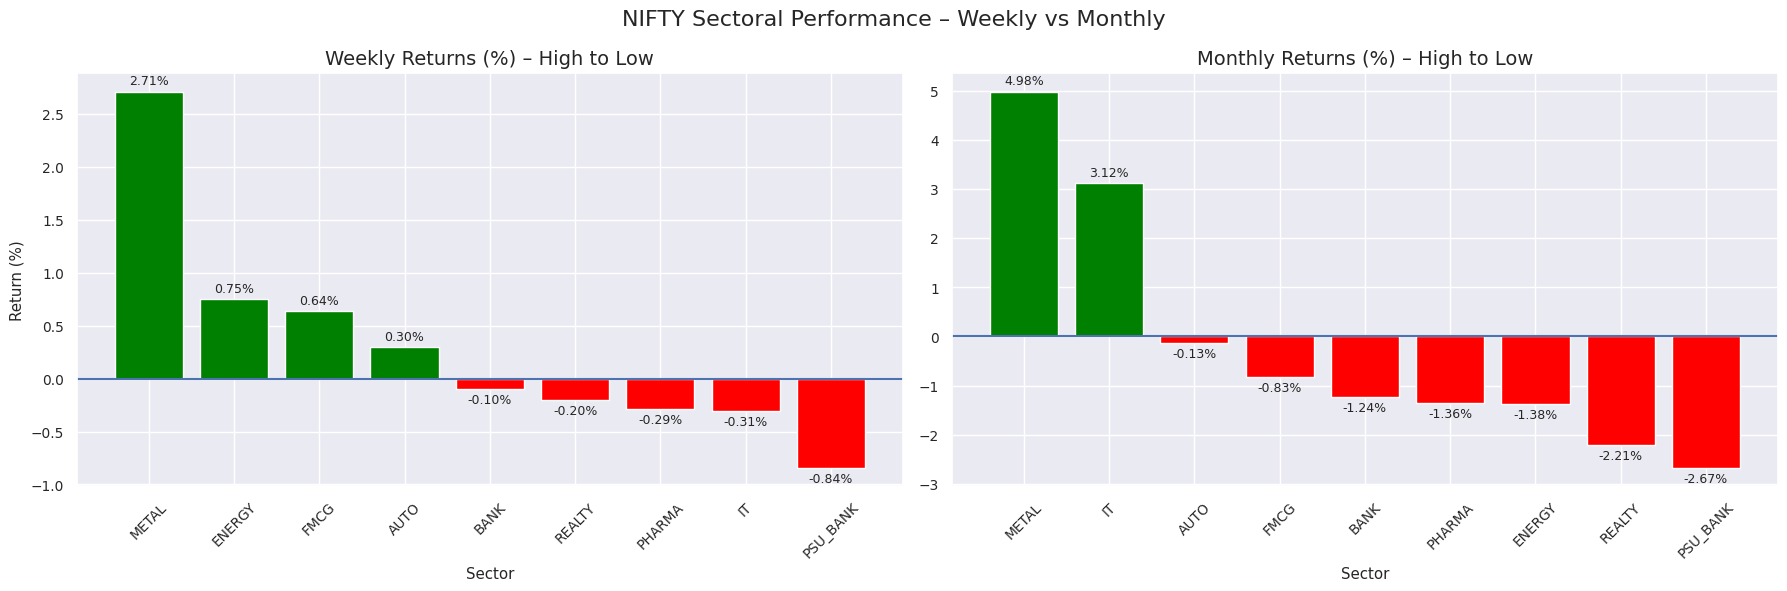

In [ ]:
import matplotlib.pyplot as plt

# ===============================
# SORT DATA (High → Low)
# ===============================
weekly_sorted  = sector_df.sort_values("Weekly %", ascending=False)
monthly_sorted = sector_df.sort_values("Monthly %", ascending=False)

weekly_vals  = weekly_sorted["Weekly %"]
monthly_vals = monthly_sorted["Monthly %"]

weekly_colors  = ['green' if x >= 0 else 'red' for x in weekly_vals]
monthly_colors = ['green' if x >= 0 else 'red' for x in monthly_vals]

# ===============================
# SPLIT VIEW PLOT
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# ---------- WEEKLY ----------
bars_w = axes[0].bar(
    weekly_sorted["Sector"],
    weekly_vals,
    color=weekly_colors
)

axes[0].axhline(0)
axes[0].set_title("Weekly Returns (%) – High to Low", fontsize=14)
axes[0].set_xlabel("Sector")
axes[0].set_ylabel("Return (%)")
axes[0].tick_params(axis='x', rotation=45)

axes[0].bar_label(
    bars_w,
    labels=[f"{v:.2f}%" for v in weekly_vals],
    padding=3,
    fontsize=9
)

# ---------- MONTHLY ----------
bars_m = axes[1].bar(
    monthly_sorted["Sector"],
    monthly_vals,
    color=monthly_colors
)

axes[1].axhline(0)
axes[1].set_title("Monthly Returns (%) – High to Low", fontsize=14)
axes[1].set_xlabel("Sector")
axes[1].tick_params(axis='x', rotation=45)

axes[1].bar_label(
    bars_m,
    labels=[f"{v:.2f}%" for v in monthly_vals],
    padding=3,
    fontsize=9
)

plt.suptitle("NIFTY Sectoral Performance – Weekly vs Monthly", fontsize=16)
plt.tight_layout()
plt.show()

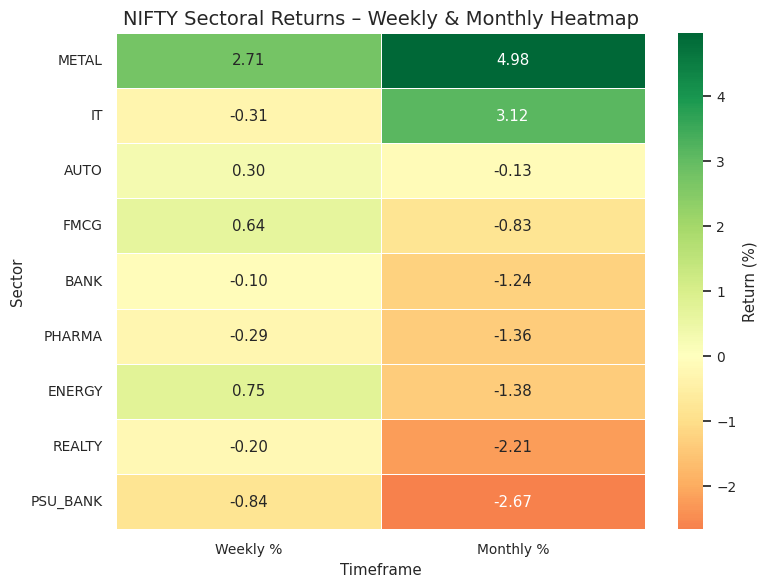

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Prepare heatmap data
# -------------------------------
heatmap_df = (
    sector_df
    .set_index("Sector")[["Weekly %", "Monthly %"]]
)

# -------------------------------
# Plot heatmap
# -------------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Return (%)"}
)

plt.title("NIFTY Sectoral Returns – Weekly & Monthly Heatmap", fontsize=14)
plt.xlabel("Timeframe")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

⚠️ Not enough weekly data for FIN_SERVICE


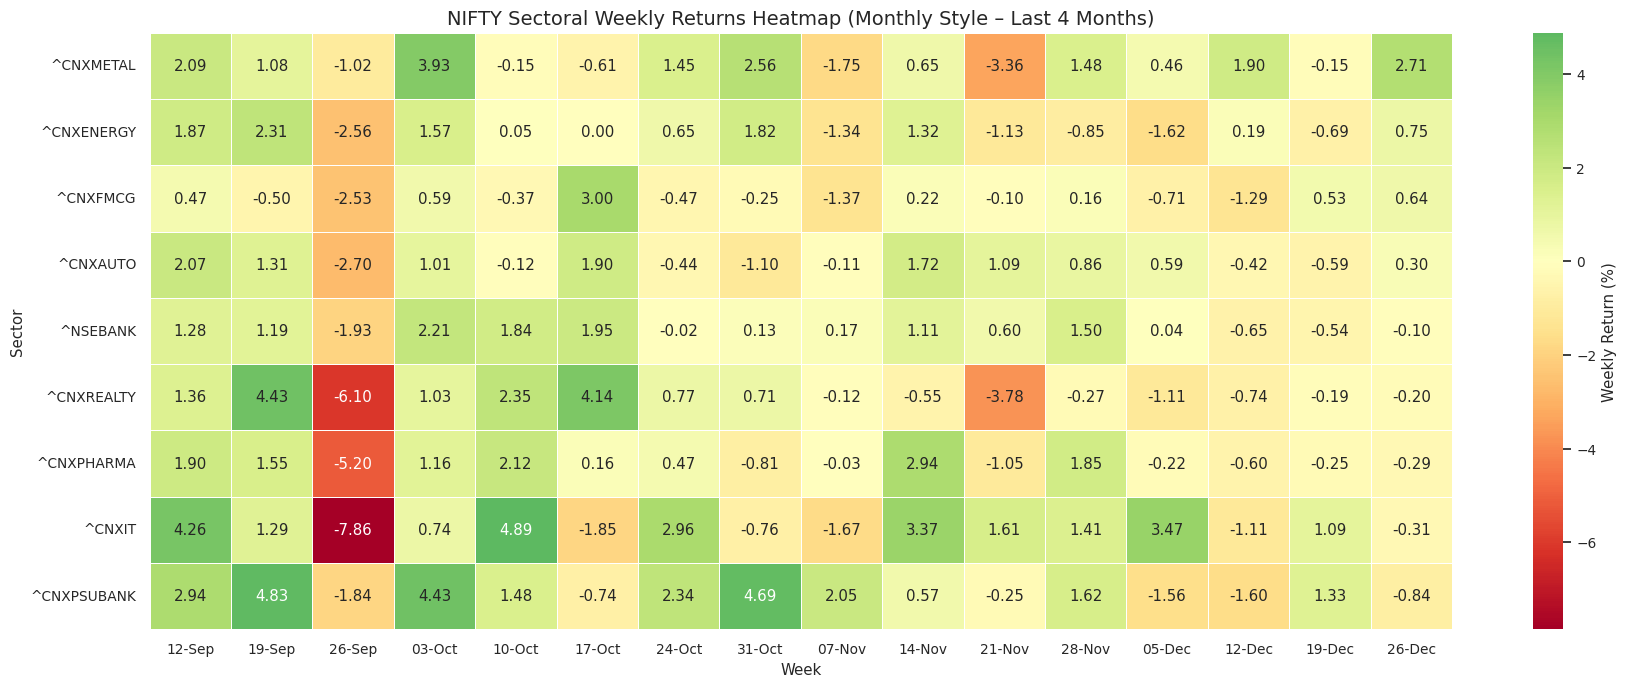

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# CONFIG
# ===============================
MONTHS_BACK = 5   # buffer for weekly calc
MIN_WEEKS   = 6   # minimum weeks required

SECTORS = {
    "AUTO": "^CNXAUTO",
    "BANK": "^NSEBANK",
    "FMCG": "^CNXFMCG",
    "IT": "^CNXIT",
    "METAL": "^CNXMETAL",
    "PHARMA": "^CNXPHARMA",
    "PSU_BANK": "^CNXPSUBANK",
    "REALTY": "^CNXREALTY",
    "ENERGY": "^CNXENERGY",
    "FIN_SERVICE": "^CNXFIN"
}

# ===============================
# DATE RANGE
# ===============================
end_date   = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(months=MONTHS_BACK)

# ===============================
# BUILD WEEKLY RETURN SERIES
# ===============================
weekly_series = []

for sector, ticker in SECTORS.items():
    df = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        print(f"⚠️ No data for {sector}")
        continue

    weekly_close = df['Close'].resample('W-FRI').last()
    weekly_ret   = weekly_close.pct_change().dropna() * 100

    if len(weekly_ret) < MIN_WEEKS:
        print(f"⚠️ Not enough weekly data for {sector}")
        continue

    weekly_ret.name = sector
    weekly_series.append(weekly_ret)

# ===============================
# SAFETY CHECK
# ===============================
if not weekly_series:
    raise ValueError("No valid sector data available for heatmap")

# ===============================
# CREATE MONTHLY-STYLE MATRIX
# ===============================
heatmap_df = pd.concat(weekly_series, axis=1).T

# Keep last ~16 weeks (≈ 4 months)
heatmap_df = heatmap_df.iloc[:, -16:]

# Format week labels (monthly-style)
heatmap_df.columns = heatmap_df.columns.strftime('%d-%b')

# Sort sectors by latest week
heatmap_df = heatmap_df.sort_values(
    by=heatmap_df.columns[-1],
    ascending=False
)

# ===============================
# PLOT HEATMAP
# ===============================
plt.figure(figsize=(18, 7))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Weekly Return (%)"}
)

plt.title(
    "NIFTY Sectoral Weekly Returns Heatmap (Monthly Style – Last 4 Months)",
    fontsize=14
)
plt.xlabel("Week")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

In [ ]:
!pip install nsekit --quiet

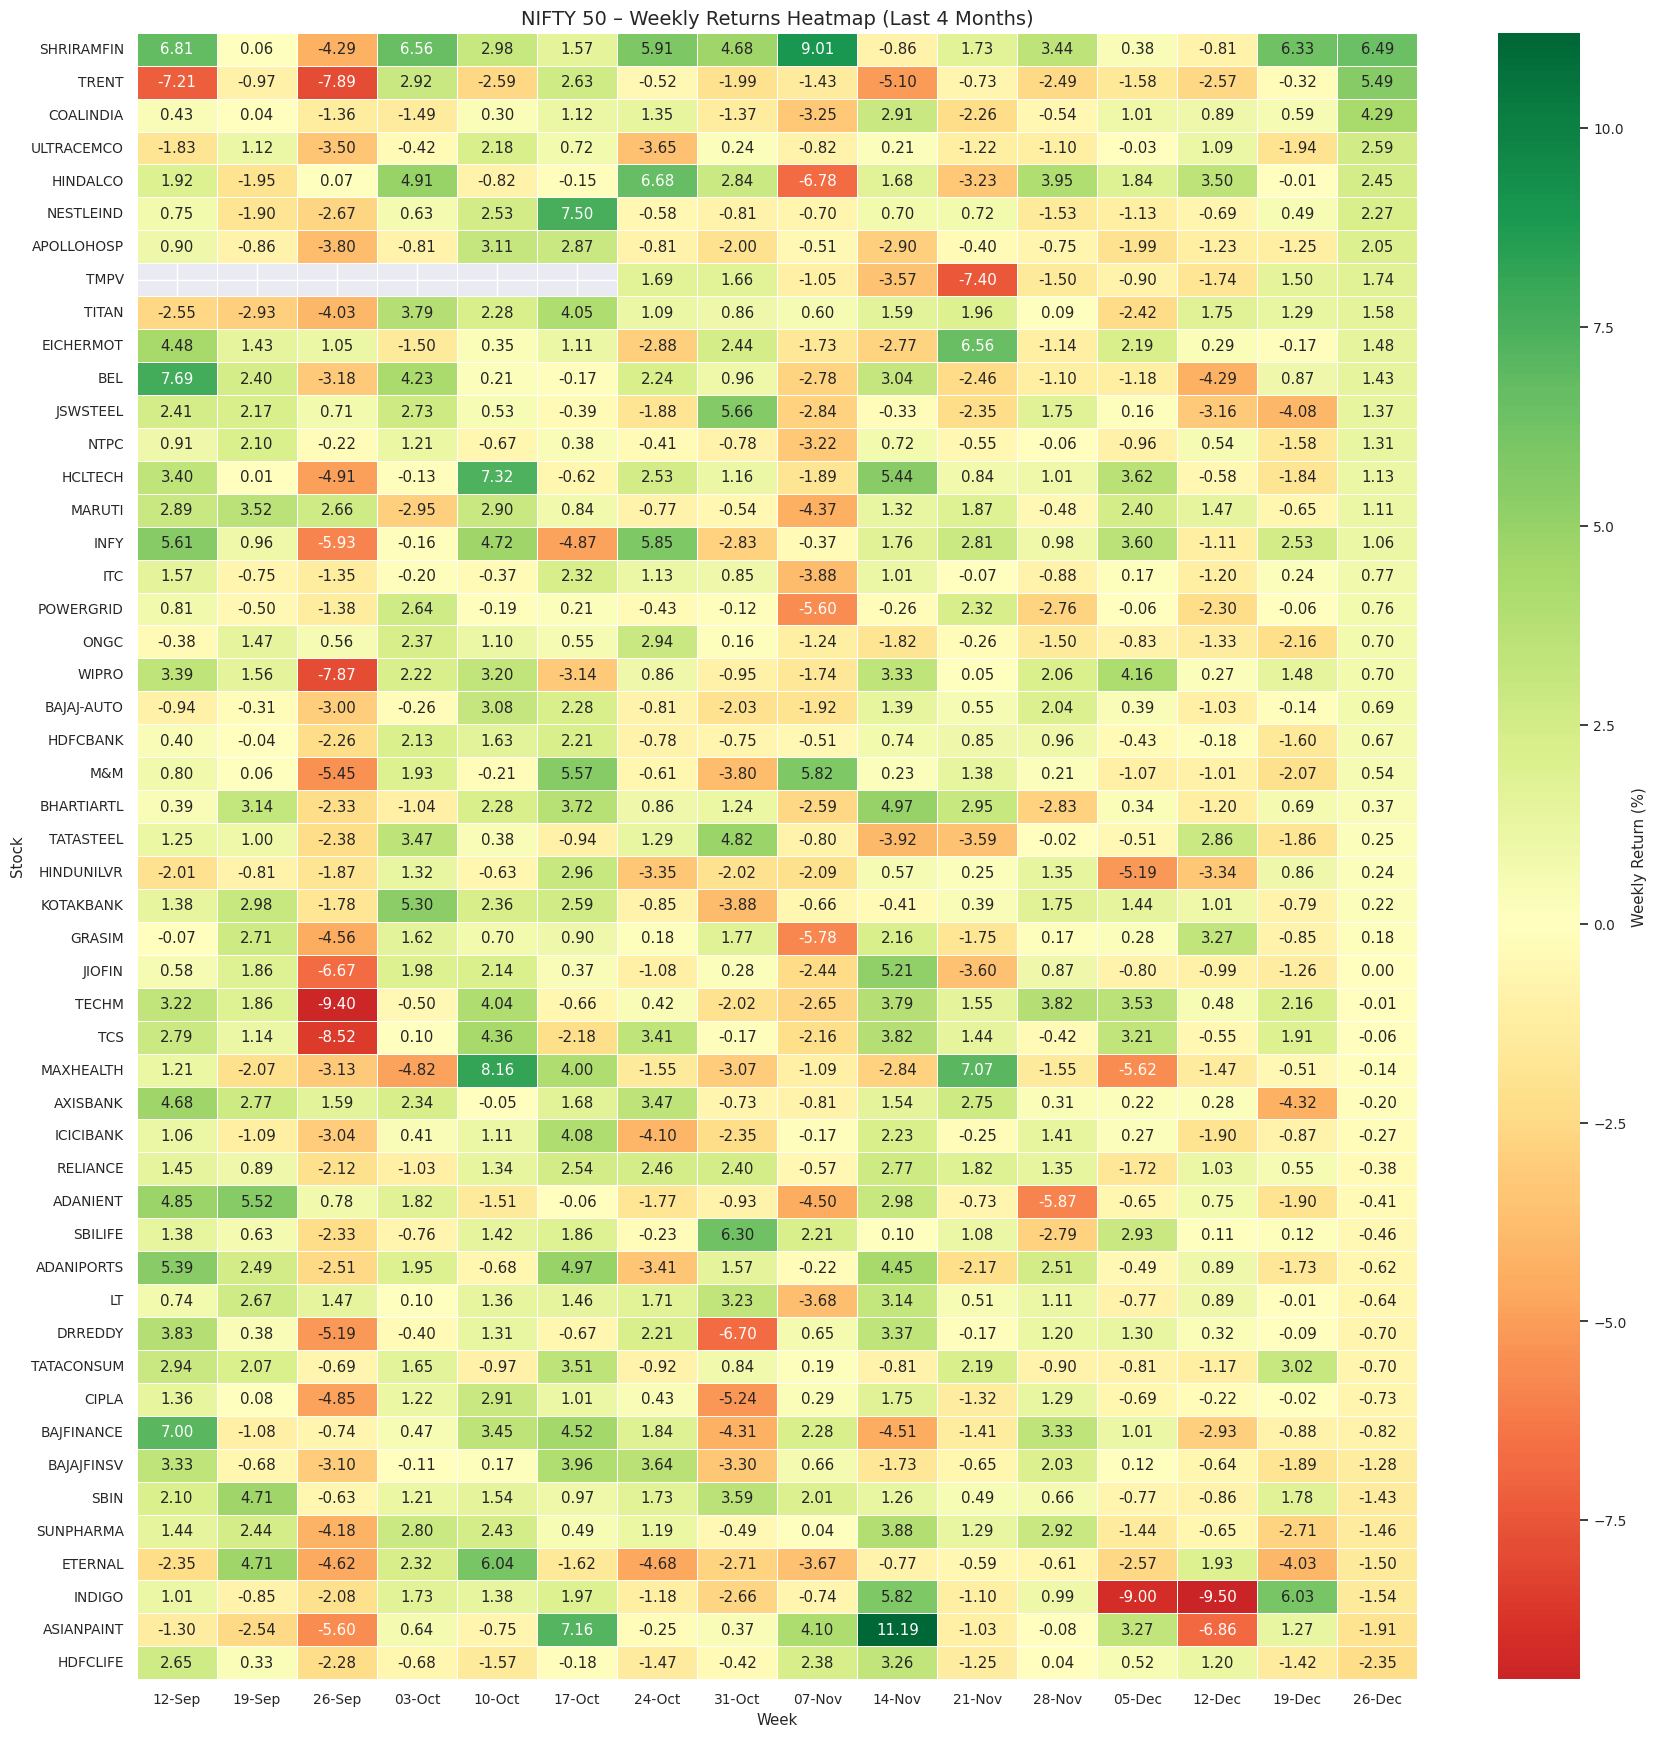

In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import NseKit
import time
from tqdm.auto import tqdm

# ===============================
# NSE INDEX CONFIG
# ===============================
get = NseKit.Nse()

INDEX_NAME = "NIFTY 50"

stocks = get.index_live_indices_stocks_data(INDEX_NAME, list_only=True)

# Add .NS for yfinance (exclude index name itself)
stocks_ns = {f"{s}.NS" for s in stocks if s != INDEX_NAME}

# ===============================
# GENERAL CONFIG
# ===============================
MONTHS_BACK = 5        # Data buffer
MIN_WEEKS   = 6        # Minimum data required
BATCH_SIZE  = 10       # yfinance safety
SLEEP_SEC   = 2        # Pause between batches

Stocks = sorted(stocks_ns)

# ===============================
# DATE RANGE
# ===============================
end_date   = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(months=MONTHS_BACK)

# ===============================
# DOWNLOAD & PROCESS DATA
# ===============================
weekly_series = []
counter = 0

with tqdm(total=len(Stocks), desc="Downloading yfinance data") as pbar:
    for ticker in Stocks:
        df = yf.download(
            ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False,
            threads=False
        )

        if not df.empty and "Close" in df.columns:
            weekly_close = df["Close"].resample("W-FRI").last()
            weekly_ret   = weekly_close.pct_change().dropna() * 100

            if len(weekly_ret) >= MIN_WEEKS:
                weekly_ret.name = ticker
                weekly_series.append(weekly_ret)

        counter += 1
        pbar.update(1)

        # Rate-limit protection
        if counter % BATCH_SIZE == 0:
            time.sleep(SLEEP_SEC)

# ===============================
# SAFETY CHECK
# ===============================
if not weekly_series:
    raise ValueError("No valid stock data available for heatmap")

# ===============================
# BUILD HEATMAP MATRIX
# ===============================
heatmap_df = pd.concat(weekly_series, axis=1).T

# Keep last ~4 months (≈16 weeks)
heatmap_df = heatmap_df.iloc[:, -16:]

# Format week labels
heatmap_df.columns = heatmap_df.columns.strftime("%d-%b")

# Sort by latest week performance
heatmap_df = heatmap_df.sort_values(
    by=heatmap_df.columns[-1],
    ascending=False
)

# Remove .NS only for display
heatmap_df.index = heatmap_df.index.str.replace(".NS", "", regex=False)

# ===============================
# AUTO FIGURE SIZE (STOCK-BASED)
# ===============================
n_stocks = heatmap_df.shape[0]
n_weeks  = heatmap_df.shape[1]

fig_height = max(6, n_stocks * 0.35)   # height scales with stocks
fig_width  = max(10, n_weeks * 1.1)    # width scales with weeks

# ===============================
# PLOT HEATMAP
# ===============================
plt.figure(figsize=(fig_width, fig_height))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Weekly Return (%)"}
)

plt.title(
    f"{INDEX_NAME} – Weekly Returns Heatmap (Last 4 Months)",
    fontsize=14
)
plt.xlabel("Week")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import numpy as np

# Assume heatmap_df is already defined
max_abs = np.max(np.abs(heatmap_df.values))

fig = px.imshow(
    heatmap_df,
    color_continuous_scale="RdYlGn",
    origin="lower",
    aspect="auto",
    labels=dict(
        x="Week",
        y="Stock",
        color="Weekly Return (%)"
    ),
    zmin=-max_abs,
    zmax=max_abs
)

fig.update_layout(
    title="Weekly Returns Heatmap (Last 4 Months)",
    height=700,
    width=1600,
    # xaxis=dict(tickangle=-45),
    yaxis=dict(autorange="reversed"),
    coloraxis_colorbar=dict(title="Weekly Return (%)")
)

fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Week: %{x}<br>Return: %{z:.2f}%<extra></extra>"
)

fig.show()